# exploitation du jeu de donnee 


In [103]:
! git clone https://YOUR_GITHUB_TOKEN@github.com/COOLMudi/CORPORATE-BANKRUPTCY-PREDICTION.git

fatal: destination path 'CORPORATE-BANKRUPTCY-PREDICTION' already exists and is not an empty directory.


# importation des librairie

In [104]:
! pip install missingno


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
! pip install imblearn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import missingno as msno
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")


from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import RFE,RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_auc_score ,roc_curve,auc
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [107]:
df_train = pd.read_csv('training_data.csv')
df_test = pd.read_csv('test_data.csv')


In [108]:
print("{0} Rows and {1} columns for Training dataset".format(df_train.shape[0],df_train.shape[1]))
print("{0} Rows and {1} columns for Test dataset".format(df_test.shape[0],df_test.shape[1]))

64074 Rows and 65 columns for Training dataset
18554 Rows and 65 columns for Test dataset


In [109]:
#Top five records in the Train data
df_train.head()

,benefice_net_sur_total_actif,total_dettes_sur_total_actif,fonds_de_roulement_sur_total_actif,actif_courant_sur_dettes_court_terme,ratio_liquidite_immediate_x365,benefices_non_distribues_sur_total_actif,EBIT_sur_total_actif,valeur_comptable_capitaux_sur_total_dettes,chiffre_affaires_sur_total_actif,capitaux_propres_sur_total_actif,...,marge_brute,cashflow_sur_marge_exploitation,total_charges_sur_total_ventes,dettes_long_terme_sur_capitaux_propres,chiffre_affaires_sur_stocks,chiffre_affaires_sur_creances,dettes_court_terme_x365_sur_chiffre_affaires,chiffre_affaires_sur_dettes_court_terme,chiffre_affaires_sur_actif_immobilise,statut_faillite
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [110]:
#Checking the Datatype of the features
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64074 entries, 0 to 64073
Data columns (total 65 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   benefice_net_sur_total_actif                                      64074 non-null  float64
 1   total_dettes_sur_total_actif                                      64074 non-null  float64
 2   fonds_de_roulement_sur_total_actif                                64074 non-null  float64
 3   actif_courant_sur_dettes_court_terme                              64074 non-null  float64
 4   ratio_liquidite_immediate_x365                                    64074 non-null  float64
 5   benefices_non_distribues_sur_total_actif                          64074 non-null  float64
 6   EBIT_sur_total_actif                                              64074 non-null  float64
 7   valeur_comptable_capitaux_sur_t

In [111]:

#Listing the names of all features
data_keys=list(df_train.columns)
len(data_keys)

65

In [112]:
#Checking the unique values in the Class-Feature
df_train['statut_faillite'].unique()

array([0, 1])

In [113]:
#Imputing class labels of train and test into Int type
from sklearn import preprocessing

# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
df_train['statut_faillite']= label_encoder.fit_transform(df_train['statut_faillite']) #
df_test['statut_faillite']= label_encoder.fit_transform(df_test['statut_faillite'])
df_train['statut_faillite'].unique()

array([0, 1])

In [114]:
df_train['statut_faillite'].dtype #The datatype for the CLASS-Feature is now converted into INT type.

dtype('int64')

In [115]:
df_train['statut_faillite'].value_counts()

statut_faillite
0    32037
1    32037
Name: count, dtype: int64

In [116]:
# À faire une seule fois avant tous vos graphiques
df_train['statut_faillite'] = df_train['statut_faillite'].astype(int)
df_test['statut_faillite']  = df_test['statut_faillite'].astype(int)

Text(0.5, 1.0, 'Distribution de la variable cible')

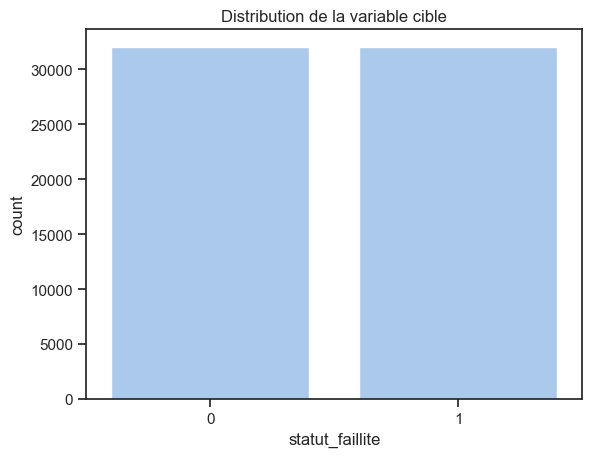

In [117]:
# diagramme en barre de la variable cible
sns.countplot(x='statut_faillite', data=df_train)
plt.title('Distribution de la variable cible')

# données manquantes 

In [209]:
total_cells = np.prod(df_train.shape)
total_missing = df_train.isnull().sum().sum()
percent_missing = (total_missing / total_cells) * 100

print(f"Cellules totales    : {total_cells:,}")
print(f"Valeurs manquantes  : {total_missing:,}")
print(f"Pourcentage manquant: {percent_missing:.2f}%")

Cellules totales    : 4,164,810
Valeurs manquantes  : 0
Pourcentage manquant: 0.00%


Text(0.5, 1.0, 'Missing values in Training Dataset')

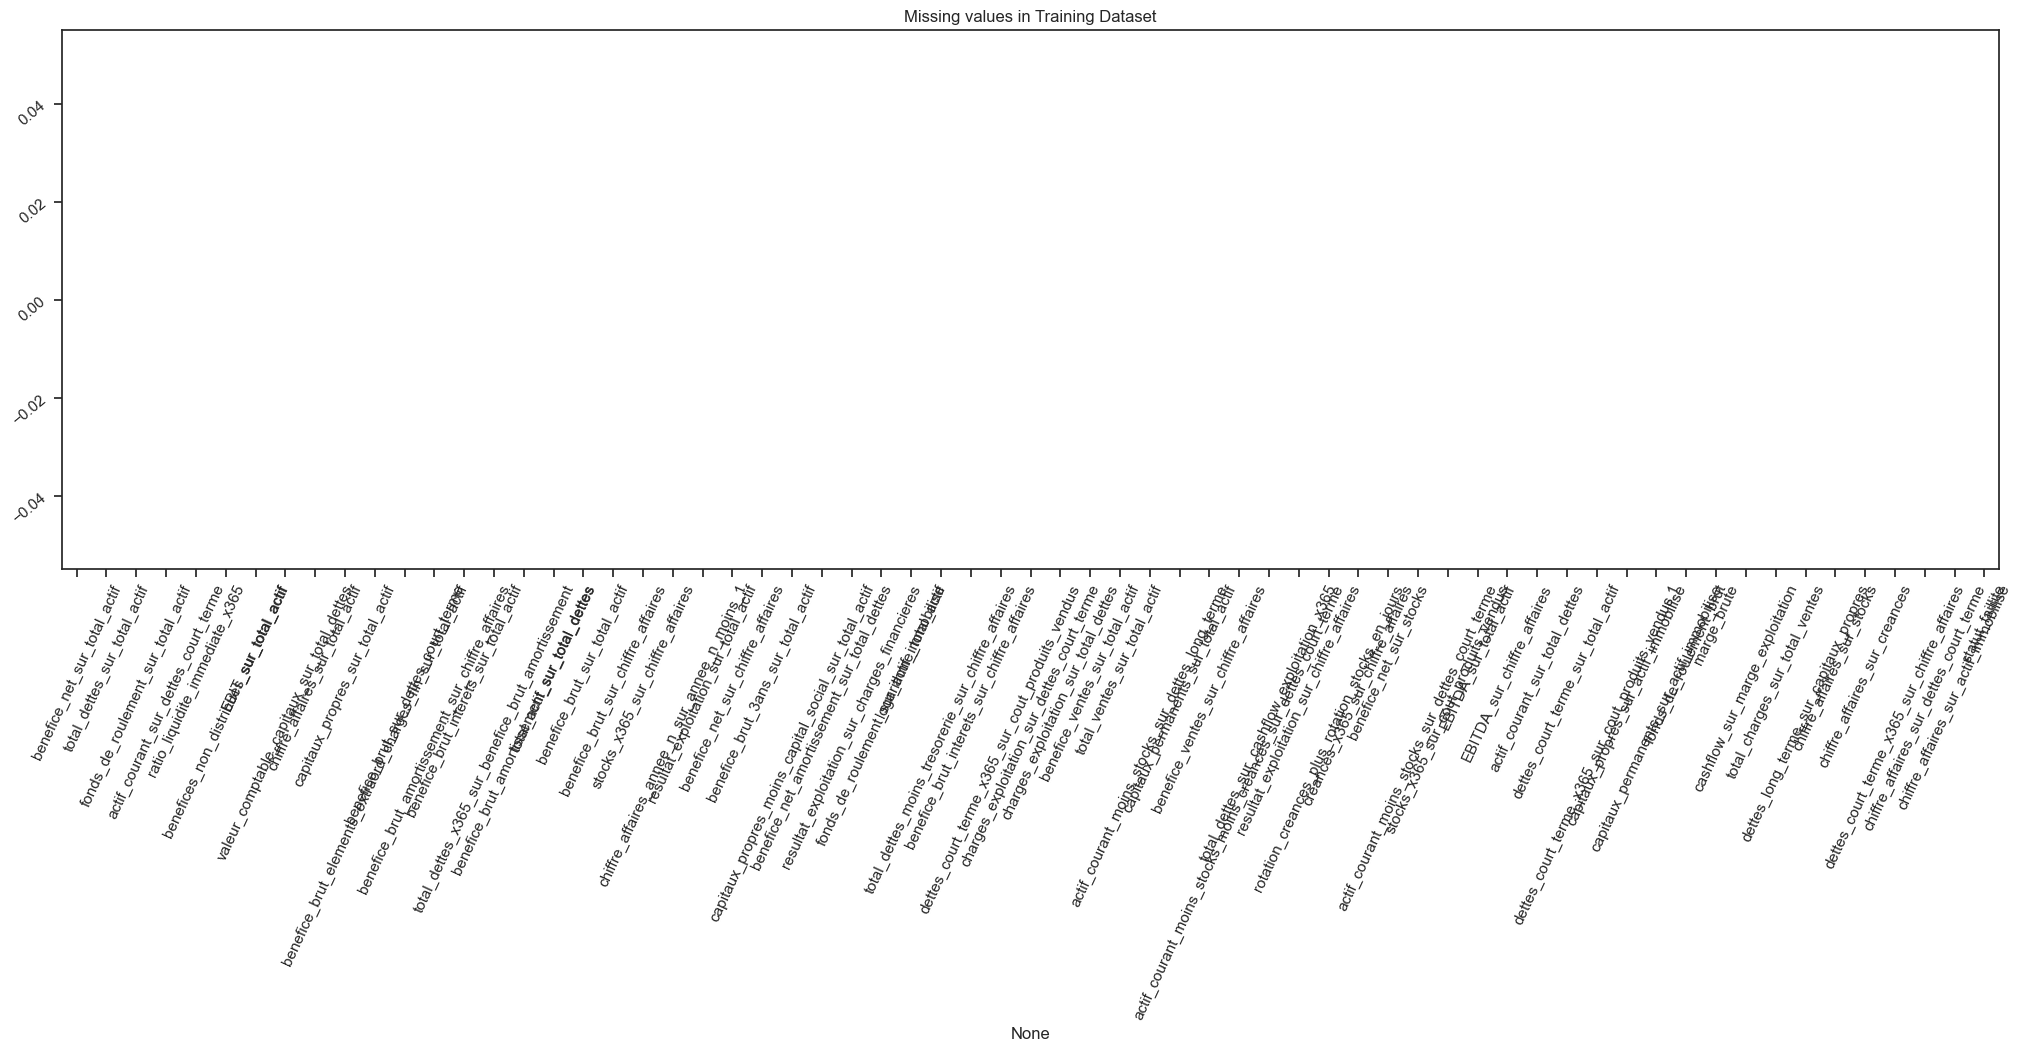

In [119]:
plt.figure(figsize = (25,7))
plt.xticks(rotation=65)
plt.yticks(rotation=40)
sns.set_theme(style = "ticks", palette = "pastel")
sns.barplot(x = df_train.columns,y = df_train.isna().sum().values)
plt.title("Missing values in Training Dataset")

<Figure size 5000x6000 with 0 Axes>

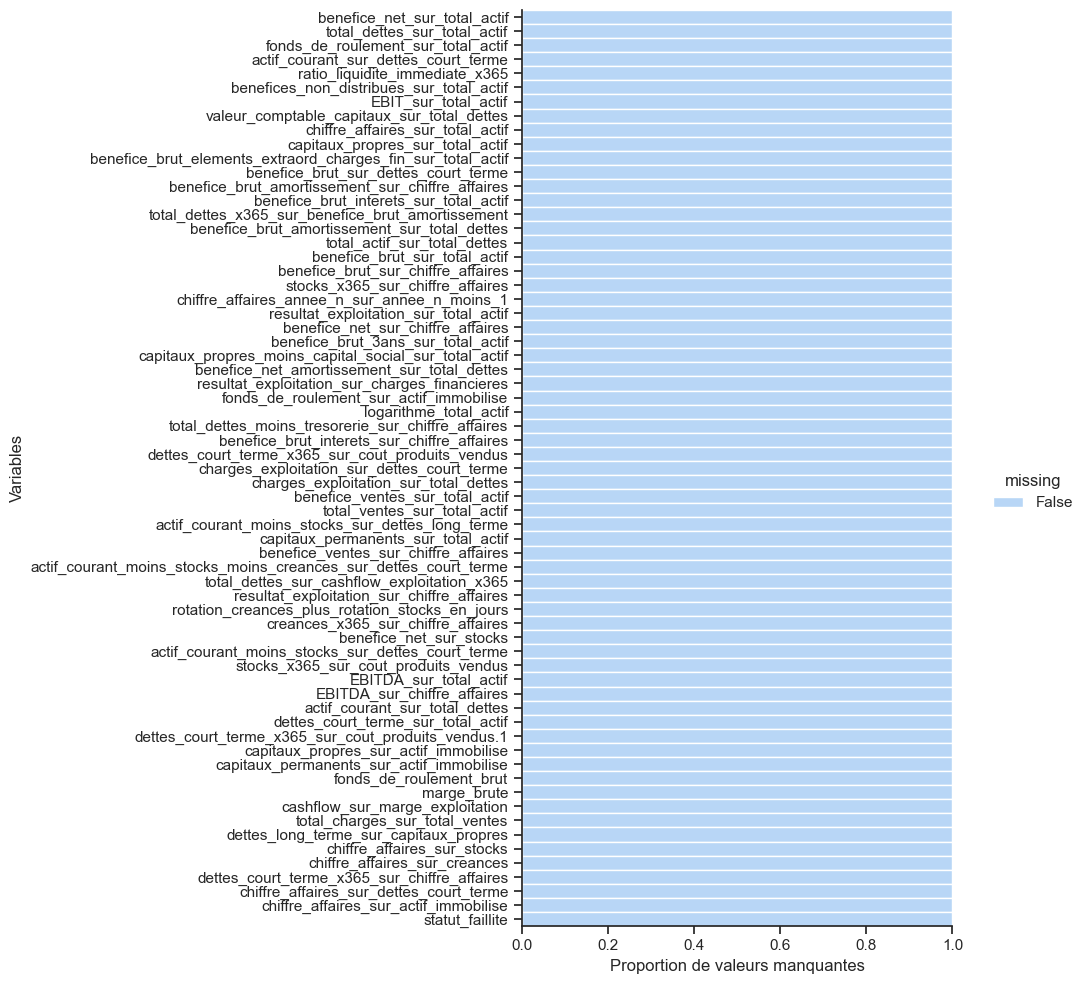

In [120]:
plt.figure(figsize=(50,60))
pltmv=sns.displot(data=df_train.isna().melt(value_name="missing"), # melt() transforme les données en format long pour seaborn
            y="variable",hue="missing", # y="variable" place les variables sur l'axe y, hue="missing" colore les barres selon la présence de valeurs manquantes
            multiple="fill",height=10,aspect=1) # multiple="fill" permet de normaliser les barres pour montrer les proportions
pltmv.set(xlabel="Proportion de valeurs manquantes", ylabel="Variables") # Personnalisation des axes
plt.savefig("visualizing_missing_data_with_barplot.png", dpi=100) # Enregistrer la figure avec une résolution de 100 dpi
plt.show()

# **Remarque :**

*Comme nous pouvons le constater, notre jeu de donnée est tres propre et ne comporte aucune anomalie ni valeur manquante.*

# Sélection de Variables

---

In [ ]:
# concat all dataset
df = pd.concat([df_train, df_test],axis = 0)


#class /label encoding
df_train['statut_faillite']= label_encoder.fit_transform(df_train['statut_faillite']) 
print(df_train['statut_faillite'].unique())


#Feature x,y
X= df_train.drop('statut_faillite',axis=1)
y=df_train['statut_faillite']

df.head()

[0 1]


,benefice_net_sur_total_actif,total_dettes_sur_total_actif,fonds_de_roulement_sur_total_actif,actif_courant_sur_dettes_court_terme,ratio_liquidite_immediate_x365,benefices_non_distribues_sur_total_actif,EBIT_sur_total_actif,valeur_comptable_capitaux_sur_total_dettes,chiffre_affaires_sur_total_actif,capitaux_propres_sur_total_actif,...,marge_brute,cashflow_sur_marge_exploitation,total_charges_sur_total_ventes,dettes_long_terme_sur_capitaux_propres,chiffre_affaires_sur_stocks,chiffre_affaires_sur_creances,dettes_court_terme_x365_sur_chiffre_affaires,chiffre_affaires_sur_dettes_court_terme,chiffre_affaires_sur_actif_immobilise,statut_faillite
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


# emputation des donnee

In [149]:
from sklearn.impute import SimpleImputer # Imputation of missing values using mean strategy

imputer = SimpleImputer(strategy="mean") # Imputation of missing values using mean strategy
X_emputer= imputer.fit_transform(X) # Imputation of missing values using mean strategy 

# selection des variable automatiquement avec lightgbm

In [151]:
from sklearn.feature_selection import RFE # Recursive Feature Elimination
import lightgbm as lgb # LightGBM is a gradient boosting framework that uses tree-based learning algorithms, designed for speed and performance.
#Feature selection  
#Recursive feature elimination

classifier = lgb.LGBMClassifier() # LightGBM is a gradient boosting framework that uses tree-based learning algorithms, designed for speed and performance.
#Select best feature 
rfe = RFE(classifier, n_features_to_select=20)
rfe = rfe.fit(X_emputer, y )

#Summarize the selection of the attributes
print(rfe.support_)
print(rfe.ranking_)
pd.DataFrame(X_emputer,columns=data_keys[:len(data_keys)-1]).columns[rfe.support_]

[LightGBM] [Info] Number of positive: 32037, number of negative: 32037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16320
[LightGBM] [Info] Number of data points in the train set: 64074, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 32037, number of negative: 32037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16065
[LightGBM] [Info] Number of data points in the train set: 64074, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 32037, number of negative: 32037
[LightGBM] [Info] Auto-choosing col-wise multi-th

Index(['actif_courant_sur_dettes_court_terme',
       'ratio_liquidite_immediate_x365',
       'benefices_non_distribues_sur_total_actif',
       'benefice_brut_sur_chiffre_affaires',
       'stocks_x365_sur_chiffre_affaires',
       'chiffre_affaires_annee_n_sur_annee_n_moins_1',
       'resultat_exploitation_sur_total_actif',
       'resultat_exploitation_sur_charges_financieres',
       'logarithme_total_actif', 'charges_exploitation_sur_total_dettes',
       'actif_courant_moins_stocks_sur_dettes_long_terme',
       'capitaux_permanents_sur_total_actif',
       'benefice_ventes_sur_chiffre_affaires',
       'creances_x365_sur_chiffre_affaires',
       'actif_courant_moins_stocks_sur_dettes_court_terme',
       'fonds_de_roulement_brut', 'total_charges_sur_total_ventes',
       'dettes_long_terme_sur_capitaux_propres', 'chiffre_affaires_sur_stocks',
       'chiffre_affaires_sur_creances'],
      dtype='object')

# convertir X_emputer en dataframe 

In [ ]:
X_emputer= pd.DataFrame(X_emputer,columns=data_keys[:len(data_keys)-1]) # 
X_fs= X_emputer[X_emputer.columns[rfe.support_]]  # 
X_fs.head()

,actif_courant_sur_dettes_court_terme,ratio_liquidite_immediate_x365,benefices_non_distribues_sur_total_actif,benefice_brut_sur_chiffre_affaires,stocks_x365_sur_chiffre_affaires,chiffre_affaires_annee_n_sur_annee_n_moins_1,resultat_exploitation_sur_total_actif,resultat_exploitation_sur_charges_financieres,logarithme_total_actif,charges_exploitation_sur_total_dettes,actif_courant_moins_stocks_sur_dettes_long_terme,capitaux_permanents_sur_total_actif,benefice_ventes_sur_chiffre_affaires,creances_x365_sur_chiffre_affaires,actif_courant_moins_stocks_sur_dettes_court_terme,fonds_de_roulement_brut,total_charges_sur_total_ventes,dettes_long_terme_sur_capitaux_propres,chiffre_affaires_sur_stocks,chiffre_affaires_sur_creances
0,2.0472,32.3510,0.38825,0.149420,43.370,1.247900,0.21402,1.45820,5.9443,0.56393,593.270000,0.50591,0.128040,71.050,1.52250,348690.0,0.87804,0.001924,8.4160,5.1372
1,1.9447,14.7860,0.00000,0.152000,87.981,1.429300,0.24806,88.44400,3.6884,2.98760,114.742766,0.49788,0.121300,111.510,1.12520,2304.6,0.85300,0.000000,4.1486,3.2732
2,1.5548,-1.1523,0.00000,0.236100,73.133,1.428300,0.30260,86.01100,4.3749,1.42740,2.301900,0.51537,0.241140,92.381,1.01010,6332.7,0.76599,0.694840,4.9909,3.9510
3,2.4928,51.9520,0.14988,0.071428,79.788,1.506900,0.11550,0.94076,4.6511,0.37581,114.742766,0.57353,0.088995,100.980,1.56960,20545.0,0.94598,0.000000,4.5746,3.6147
4,1.4063,-7.3128,0.18732,0.115530,57.045,4.805113,0.19832,1.41380,4.1424,0.32340,11.247000,0.43489,0.122310,84.574,0.95787,3186.6,0.86515,0.124440,6.3985,4.3158


<Axes: >

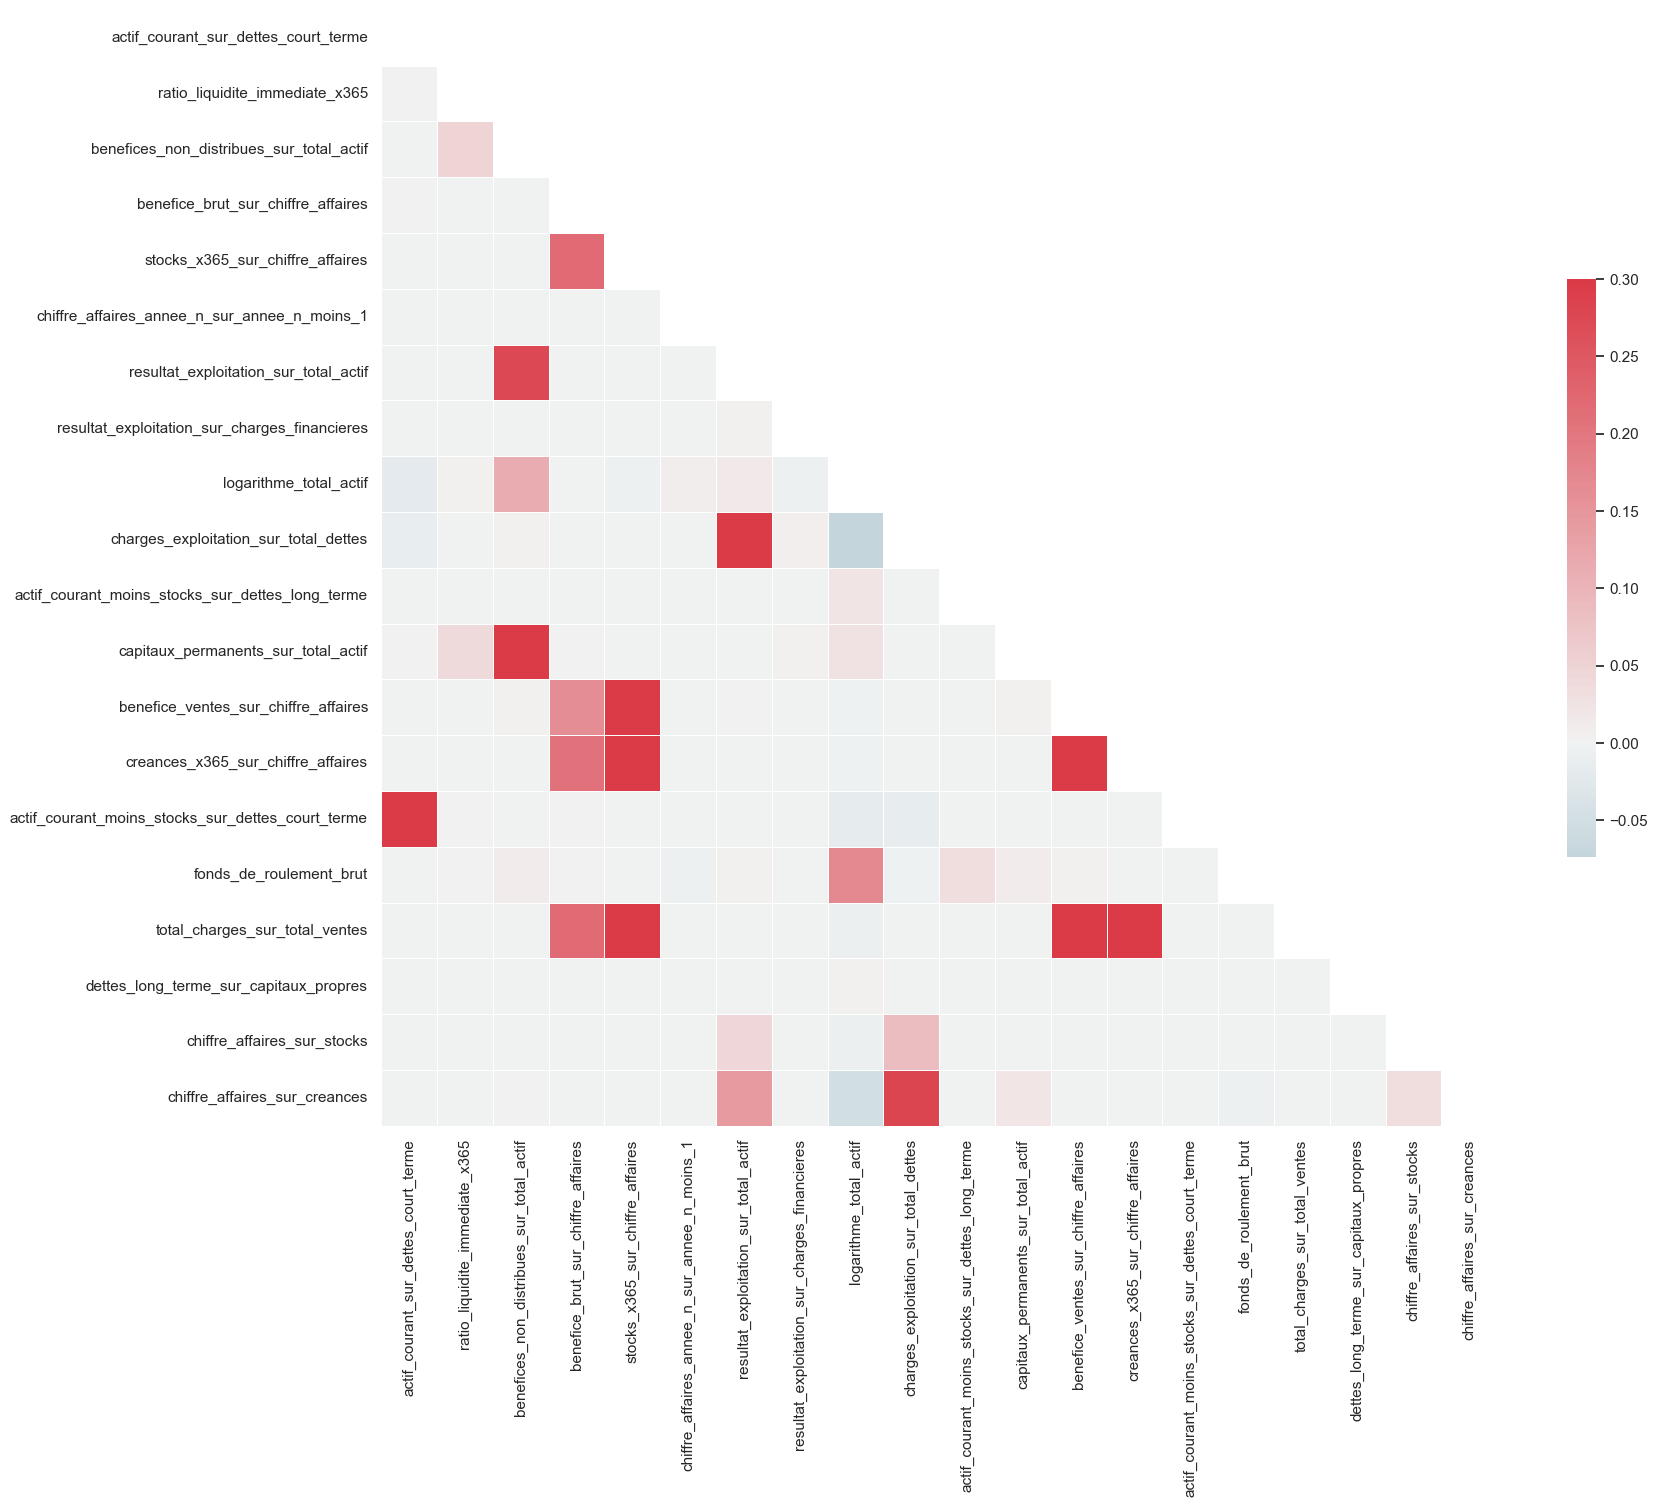

In [153]:
# New Correlation Matrix
sns.set(style="white")

# Compute the correlation matrix
corr = X_fs.corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})  

# Gestion du Déséquilibre des Classes


### application du smot pour equilibrer les classe de mavariable cible 

In [155]:
df_train= pd.DataFrame(imputer.fit_transform(df_train),columns=data_keys)
df_test= pd.DataFrame(imputer.fit_transform(df_test),columns=data_keys)

#copy of data a
xtrain=df_train.drop('statut_faillite',axis=1).copy()
xtest=df_test.drop('statut_faillite',axis=1).copy()
y1=df_train['statut_faillite']; y2=df_test['statut_faillite']

#oversampling 
X_train1, y_train1 = oversample.fit_resample(xtrain,y1)
X_test1, y_test1 = oversample.fit_resample(xtest,y2)

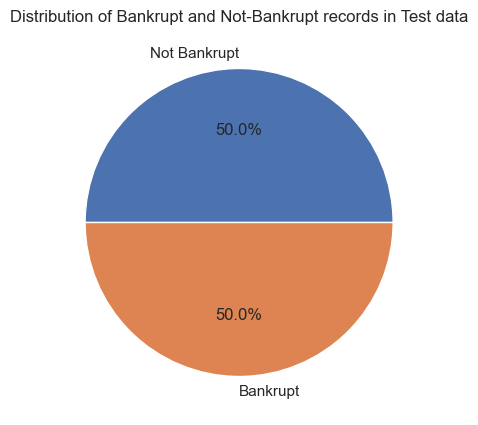

In [154]:
plt.figure(figsize = (7,5))
labels = ["Not Bankrupt", "Bankrupt"]
plt.pie(df_train['statut_faillite'].value_counts().values,labels = labels, autopct='%.1f%%')
plt.title("Distribution of Bankrupt and Not-Bankrupt records in Test data")
plt.show()

 X_fs → Variables sélectionnées après feature selection — 24 attributs
 y → Variable cible (label) — statut_faillite (0 = saine / 1 = faillite)

In [156]:
X_fs.head()

,actif_courant_sur_dettes_court_terme,ratio_liquidite_immediate_x365,benefices_non_distribues_sur_total_actif,benefice_brut_sur_chiffre_affaires,stocks_x365_sur_chiffre_affaires,chiffre_affaires_annee_n_sur_annee_n_moins_1,resultat_exploitation_sur_total_actif,resultat_exploitation_sur_charges_financieres,logarithme_total_actif,charges_exploitation_sur_total_dettes,actif_courant_moins_stocks_sur_dettes_long_terme,capitaux_permanents_sur_total_actif,benefice_ventes_sur_chiffre_affaires,creances_x365_sur_chiffre_affaires,actif_courant_moins_stocks_sur_dettes_court_terme,fonds_de_roulement_brut,total_charges_sur_total_ventes,dettes_long_terme_sur_capitaux_propres,chiffre_affaires_sur_stocks,chiffre_affaires_sur_creances
0,2.0472,32.3510,0.38825,0.149420,43.370,1.247900,0.21402,1.45820,5.9443,0.56393,593.270000,0.50591,0.128040,71.050,1.52250,348690.0,0.87804,0.001924,8.4160,5.1372
1,1.9447,14.7860,0.00000,0.152000,87.981,1.429300,0.24806,88.44400,3.6884,2.98760,114.742766,0.49788,0.121300,111.510,1.12520,2304.6,0.85300,0.000000,4.1486,3.2732
2,1.5548,-1.1523,0.00000,0.236100,73.133,1.428300,0.30260,86.01100,4.3749,1.42740,2.301900,0.51537,0.241140,92.381,1.01010,6332.7,0.76599,0.694840,4.9909,3.9510
3,2.4928,51.9520,0.14988,0.071428,79.788,1.506900,0.11550,0.94076,4.6511,0.37581,114.742766,0.57353,0.088995,100.980,1.56960,20545.0,0.94598,0.000000,4.5746,3.6147
4,1.4063,-7.3128,0.18732,0.115530,57.045,4.805113,0.19832,1.41380,4.1424,0.32340,11.247000,0.43489,0.122310,84.574,0.95787,3186.6,0.86515,0.124440,6.3985,4.3158


In [157]:
X_fs.shape

(64074, 20)

In [158]:
y.shape

(64074,)

# Découpage Stratifié Train/Test

In [ ]:
# split into train test sets (  Découpage en ensembles d'entraînement et de test )
from sklearn.model_selection import train_test_split # 
X_train, X_test, y_train, y_test = train_test_split(X_fs, y, test_size=0.25, random_state=1, stratify=y) # 

In [160]:
print(X_train.shape)
X_train.head()

(48055, 20)


,actif_courant_sur_dettes_court_terme,ratio_liquidite_immediate_x365,benefices_non_distribues_sur_total_actif,benefice_brut_sur_chiffre_affaires,stocks_x365_sur_chiffre_affaires,chiffre_affaires_annee_n_sur_annee_n_moins_1,resultat_exploitation_sur_total_actif,resultat_exploitation_sur_charges_financieres,logarithme_total_actif,charges_exploitation_sur_total_dettes,actif_courant_moins_stocks_sur_dettes_long_terme,capitaux_permanents_sur_total_actif,benefice_ventes_sur_chiffre_affaires,creances_x365_sur_chiffre_affaires,actif_courant_moins_stocks_sur_dettes_court_terme,fonds_de_roulement_brut,total_charges_sur_total_ventes,dettes_long_terme_sur_capitaux_propres,chiffre_affaires_sur_stocks,chiffre_affaires_sur_creances
60349,2.009313,-5.462819,-0.059816,-0.006905,27.183917,1.074830,-0.032244,-1.530209,2.833418,16.969953,111.494169,0.534177,-0.002934,15.879179,1.270553,321.061090,1.004002,0.040855,13.428191,23.028602
35879,0.276142,-356.558519,-0.325643,-0.157246,60.257846,1.032994,0.034559,1105.575451,4.187617,0.010619,100.713545,-1.817807,0.015431,38.676034,0.135302,-22737.025069,1.174282,0.109243,6.317784,10.952613
44513,1.251696,-64.140594,0.004765,0.001687,86.828874,1.674097,0.018006,849.335235,4.467165,0.860481,4.844527,0.472967,0.009195,55.580001,0.534500,3139.787929,0.990925,0.138425,4.944564,6.569563
39598,0.799800,-109.370000,-0.121890,0.048802,63.593000,4.805113,0.119100,4.034100,3.576300,2.026000,4.998700,0.177770,0.060767,46.474000,0.381400,-590.000000,0.967330,0.504920,5.739700,7.853900
2882,2.770600,75.207000,0.000000,0.093604,26.244000,1.353700,0.217140,71.220000,3.917500,4.879300,114.742766,0.564670,0.090657,66.852000,2.297400,5196.700000,0.907530,0.000000,13.908000,5.459900


In [211]:
y_train.value_counts()
nzero=y_train.value_counts()[0];
n1= y_train.value_counts()[1]
ratio_train = n1/nzero
print('ratio_train=',ratio_train)

ratio_train= 0.9999583818877976


In [ ]:
y_test.value_counts() 
y_train.value_counts()
nzero=y_test.value_counts()[0]; 
n1= y_test.value_counts()[1]
ratio_test = n1/nzero
print('ratio_test=',ratio_test)
print()
print('difference in ratio : train-test=',int(np.abs(ratio_train-ratio_test)))

ratio_test= 1.0001248595330254

difference in ratio : train-test= 0


# model 1 : Model de regression logistique 

In [212]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(penalty='l2', max_iter=1000)

param = {'C': [0.001, 0.003, 0.005, 0.01, 0.03, 0.05,
               0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 10, 20]}

clf = GridSearchCV(logreg, param, scoring='roc_auc', cv=5, n_jobs=-1)
clf.fit(X_train, y_train)

print('Meilleur AUC-ROC : {:.4f} | Meilleur C : {}'.format(
      clf.best_score_, clf.best_params_))

Meilleur AUC-ROC : 0.6981 | Meilleur C : {'C': 0.005}


=== Rapport de Classification ===
              precision    recall  f1-score   support

   Saine (0)       0.53      0.93      0.68      8009
Faillite (1)       0.72      0.19      0.30      8010

    accuracy                           0.56     16019
   macro avg       0.63      0.56      0.49     16019
weighted avg       0.63      0.56      0.49     16019

AUC-ROC : 0.7054


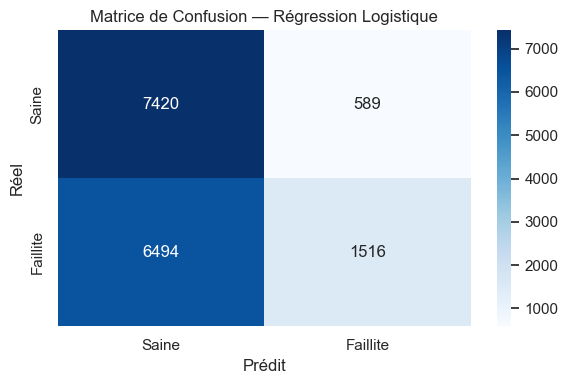

In [165]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Rapport de classification
print("=== Rapport de Classification ===")
print(classification_report(y_test, y_pred, target_names=['Saine (0)', 'Faillite (1)']))

# AUC-ROC
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saine', 'Faillite'],
            yticklabels=['Saine', 'Faillite'])
plt.title('Matrice de Confusion — Régression Logistique')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [163]:
model = LogisticRegression(random_state=42,penalty='l2',C=0.001)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy : ",round(accuracy_score(y_test, y_pred)*100,2))
print(" Train Accuracy : ",round(accuracy_score(y_train, model.predict(X_train))*100,2))

Accuracy :  56.43
 Train Accuracy :  56.57


In [166]:

kf = StratifiedKFold(n_splits=5,shuffle=True)
pred_test_full =0
cv_score =[]
i=1
for train_index,test_index in kf.split(X_train,y_train):
    print('{} of KFold {}'.format(i,kf.n_splits))
    xtr,xvl = X_train.iloc[train_index],X_train.iloc[test_index]
    ytr,yvl = y_train.iloc[train_index],y_train.iloc[test_index]
    
    #model
    lr = LogisticRegression(penalty='l2')
    lr.fit(xtr,ytr)
    score = accuracy_score(yvl,lr.predict(xvl))
    print('Accuracy Score:',score)
    cv_score.append(score)    
    pred_test = lr.predict_proba(X_test)[:,1]
    pred_test_full +=pred_test    
    i+=1

1 of KFold 5
Accuracy Score: 0.5782957028404953
2 of KFold 5
Accuracy Score: 0.5695557174071376
3 of KFold 5
Accuracy Score: 0.5765268962646967
4 of KFold 5
Accuracy Score: 0.5740297575694516
5 of KFold 5
Accuracy Score: 0.5572781188221829


In [167]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, model.predict(X_test))
print(cm)

[[7007 1002]
 [5978 2032]]


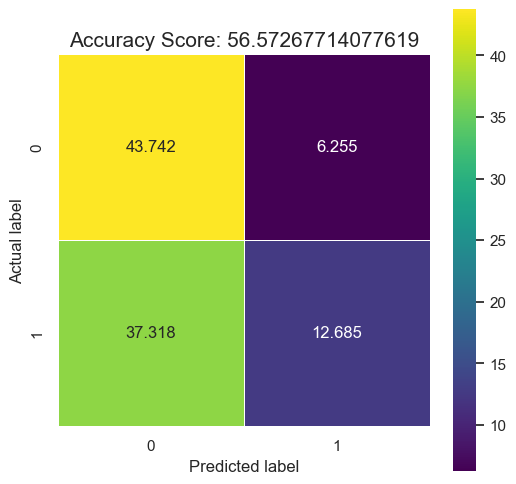

In [168]:
plt.figure(figsize=(6,6))
sns.heatmap((cm/np.sum(cm)*100), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'viridis');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_score(y_train, model.predict(X_train))*100)
plt.title(all_sample_title, size = 15);

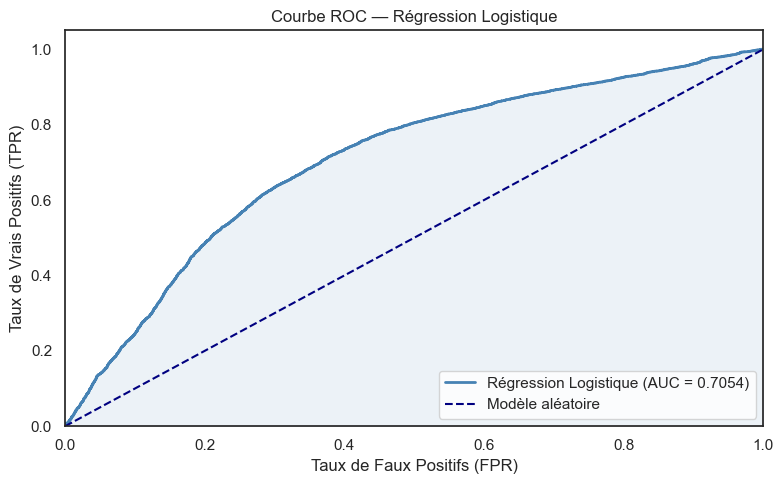

AUC-ROC : 0.7054


In [180]:
# ================================
# Courbe ROC — Régression Logistique
# ================================
y_prob_lr = clf.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Régression Logistique (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Modèle aléatoire')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC — Régression Logistique')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC-ROC : {auc_lr:.4f}")

In [169]:
from sklearn.metrics import accuracy_score, f1_score,recall_score,precision_score, confusion_matrix
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
results = pd.DataFrame([['Logistic Regression ', acc*100,prec*100,rec*100,f1*100]],
                       columns=['Model', 'Accuracy', 'Precision', 'Recall','F1 Score'])
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,55.783757,72.019002,18.926342,29.975284


#  Model 2 : Bernoulli Naive Bayes Classifier

---



In [170]:
from sklearn.naive_bayes import BernoulliNB
model3 = BernoulliNB()
model3.fit(X_train, y_train)

y_pred2 = model3.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy : ",round(accuracy_score(y_test, y_pred2)*100,2))
print(classification_report(y_test, y_pred2))

Accuracy :  64.41
              precision    recall  f1-score   support

           0       0.62      0.74      0.67      8009
           1       0.68      0.55      0.61      8010

    accuracy                           0.64     16019
   macro avg       0.65      0.64      0.64     16019
weighted avg       0.65      0.64      0.64     16019



[[5898 2111]
 [3590 4420]]


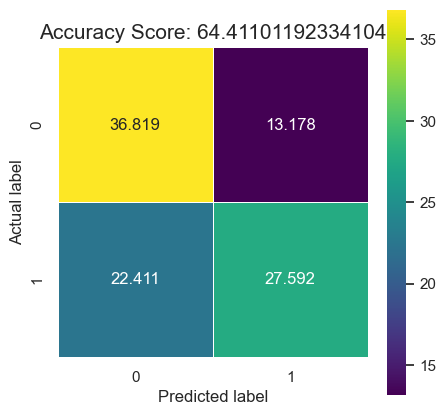

In [171]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, y_pred2)
print(cm)

plt.figure(figsize=(5,5))
sns.heatmap((cm/np.sum(cm)*100), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'viridis');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_score(y_test, y_pred2)*100)
plt.title(all_sample_title, size = 15);

In [172]:
acc = accuracy_score(y_test, y_pred2)
prec = precision_score(y_test, y_pred2)
rec = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)
results.loc[len(results.index)] =['BNB classifier', acc*100,
                                  prec*100,rec*100,f1*100]



---

# Model 3 : LGBM Classifier

In [173]:
import lightgbm as lgb
model4 = lgb.LGBMClassifier()
model4.fit(X_train, y_train)

y_pred2 = model4.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy : ",round(accuracy_score(y_test, y_pred2)*100,2))
print(classification_report(y_test, y_pred2))

[LightGBM] [Info] Number of positive: 24027, number of negative: 24028
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003619 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 48055, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499990 -> initscore=-0.000042
[LightGBM] [Info] Start training from score -0.000042
Accuracy :  97.18
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      8009
           1       0.98      0.97      0.97      8010

    accuracy                           0.97     16019
   macro avg       0.97      0.97      0.97     16019
weighted avg       0.97      0.97      0.97     16019



[[7824  185]
 [ 266 7744]]


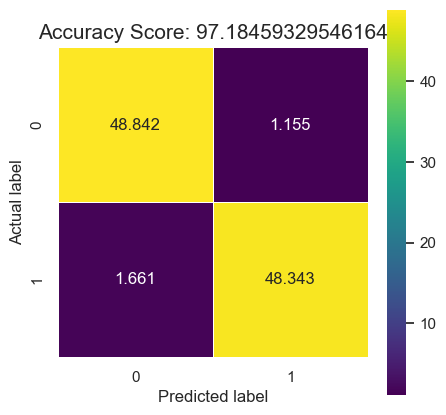

In [174]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, y_pred2)
print(cm)

plt.figure(figsize=(5,5))
sns.heatmap((cm/np.sum(cm)*100), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'viridis');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_score(y_test, y_pred2)*100)
plt.title(all_sample_title, size = 15);

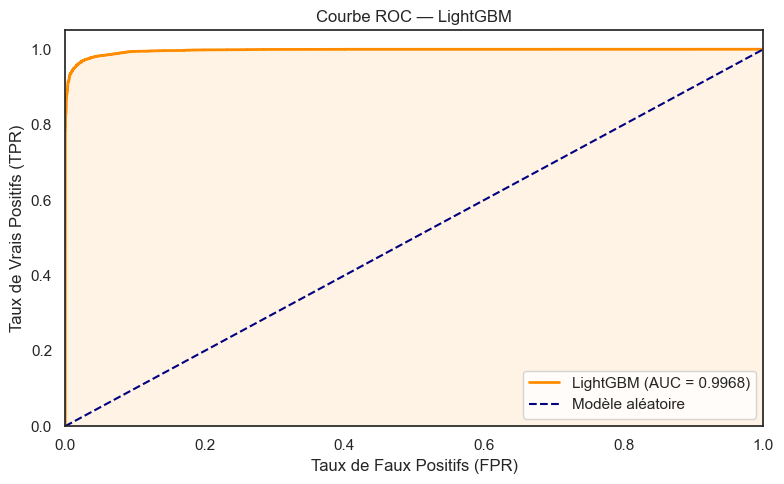

AUC-ROC : 0.9968


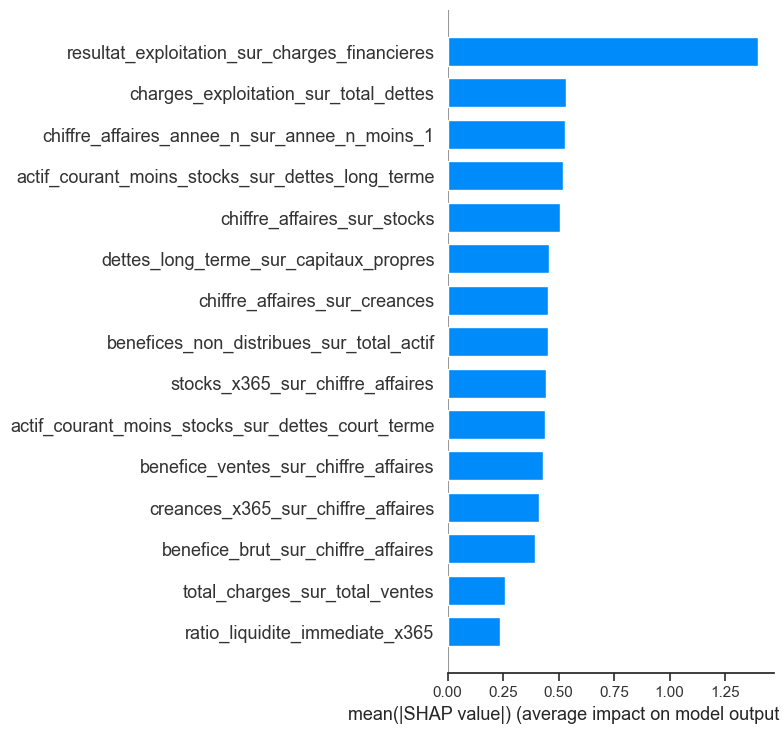

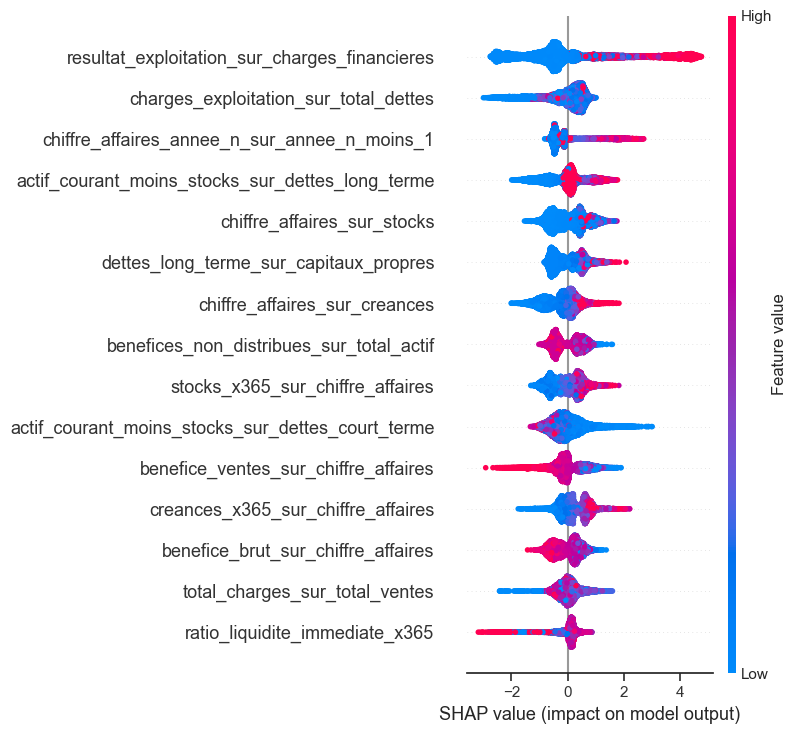

In [189]:
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# ================================
# 1. AUC-ROC + Courbe ROC
# ================================
y_prob_lgbm = model4.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lgbm)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgbm)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'LightGBM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Modèle aléatoire')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC — LightGBM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC-ROC : {auc:.4f}")

# ================================
# 2. SHAP — Importance des Variables
# ================================
explainer = shap.TreeExplainer(model4 )
shap_values = explainer.shap_values(X_test)

# Graphique 1 — Importance globale (bar plot)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  max_display=15,
                  show=True)

# Graphique 2 — Impact détaillé (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=True)

In [176]:
acc = accuracy_score(y_test, y_pred2)
prec = precision_score(y_test, y_pred2)
rec = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)
results.loc[len(results.index)] =['LGBM classifier', acc*100,
                                  prec*100,rec*100,f1*100]



# Model 4 : AdaBoost Classifier

In [177]:
from sklearn.ensemble import AdaBoostClassifier
model5 = AdaBoostClassifier()
model5.fit(X_train, y_train)

y_pred2 = model5.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy : ",round(accuracy_score(y_test, y_pred2)*100,2))
print(classification_report(y_test, y_pred2))

Accuracy :  85.43
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      8009
           1       0.87      0.83      0.85      8010

    accuracy                           0.85     16019
   macro avg       0.85      0.85      0.85     16019
weighted avg       0.85      0.85      0.85     16019



[[6998 1011]
 [1323 6687]]


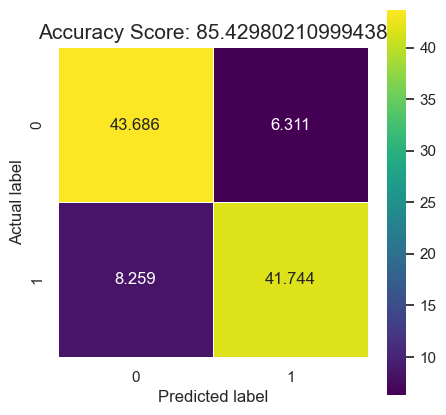

In [190]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, y_pred2)
print(cm)

plt.figure(figsize=(5,5))
sns.heatmap((cm/np.sum(cm)*100), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'viridis');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_score(y_test, y_pred2)*100)
plt.title(all_sample_title, size = 15);

In [191]:
acc = accuracy_score(y_test, y_pred2)
prec = precision_score(y_test, y_pred2)
rec = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)
results.loc[len(results.index)] =['AdaBoost', acc*100,
                                  prec*100,rec*100,f1*100]

# model 5 : XGBOOST  

In [195]:
xgb_reg = XGBClassifier(
    n_estimators=300,
    max_depth=4,          # ← réduire la profondeur (défaut=6)
    learning_rate=0.05,   # ← ralentir l'apprentissage
    subsample=0.8,        # ← utiliser 80% des lignes par arbre
    colsample_bytree=0.8, # ← utiliser 80% des variables par arbre
    reg_alpha=0.1,        # ← régularisation L1
    reg_lambda=1.0,       # ← régularisation L2
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False)

# Vérification train vs test
y_pred_train_reg = xgb_reg.predict(X_train)
y_pred_test_reg  = xgb_reg.predict(X_test)

print("=== TRAIN ===")
print(classification_report(y_train, y_pred_train_reg,
      target_names=['Saine (0)', 'Faillite (1)']))

print("=== TEST ===")
print(classification_report(y_test, y_pred_test_reg,
      target_names=['Saine (0)', 'Faillite (1)']))

print(f"AUC-ROC : {roc_auc_score(y_test, xgb_reg.predict_proba(X_test)[:,1]):.4f}")

=== TRAIN ===
              precision    recall  f1-score   support

   Saine (0)       0.96      0.97      0.97     24028
Faillite (1)       0.97      0.96      0.96     24027

    accuracy                           0.97     48055
   macro avg       0.97      0.97      0.97     48055
weighted avg       0.97      0.97      0.97     48055

=== TEST ===
              precision    recall  f1-score   support

   Saine (0)       0.95      0.97      0.96      8009
Faillite (1)       0.97      0.95      0.96      8010

    accuracy                           0.96     16019
   macro avg       0.96      0.96      0.96     16019
weighted avg       0.96      0.96      0.96     16019

AUC-ROC : 0.9935


In [194]:
# Vérifier si le modèle overfit
y_pred_train = xgb.predict(X_train)
print("=== Performance sur TRAIN ===")
print(classification_report(y_train, y_pred_train,
      target_names=['Saine (0)', 'Faillite (1)']))

=== Performance sur TRAIN ===
              precision    recall  f1-score   support

   Saine (0)       1.00      1.00      1.00     24028
Faillite (1)       1.00      1.00      1.00     24027

    accuracy                           1.00     48055
   macro avg       1.00      1.00      1.00     48055
weighted avg       1.00      1.00      1.00     48055



# Model : ramdom forest

In [200]:
model_rf_reg = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # ← limiter la profondeur
    min_samples_split=10,  # ← minimum 10 exemples pour splitter
    min_samples_leaf=5,    # ← minimum 5 exemples par feuille
    max_features='sqrt',   # ← sélection aléatoire des variables
    random_state=42,
    n_jobs=-1
)

model_rf_reg.fit(X_train2, y_train2)

y_pred_rf_reg       = model_rf_reg.predict(X_test2)
y_pred_rf_reg_train = model_rf_reg.predict(X_train2)

print("=== Random Forest Régularisé ===")
print(f"Accuracy Train : {round(accuracy_score(y_train2, y_pred_rf_reg_train) * 100, 2)}%")
print(f"Accuracy Test  : {round(accuracy_score(y_test2, y_pred_rf_reg) * 100, 2)}%")
print()
print(classification_report(y_test2, y_pred_rf_reg,
      target_names=['Saine (0)', 'Faillite (1)']))

=== Random Forest Régularisé ===
Accuracy Train : 92.62%
Accuracy Test  : 91.41%

              precision    recall  f1-score   support

   Saine (0)       0.92      0.91      0.91      9612
Faillite (1)       0.91      0.92      0.91      9611

    accuracy                           0.91     19223
   macro avg       0.91      0.91      0.91     19223
weighted avg       0.91      0.91      0.91     19223



In [199]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Imputation
# ================================
imputer = SimpleImputer(strategy="mean")
X_imp = imputer.fit_transform(X_fs)
X1 = pd.DataFrame(X_imp, columns=X_fs.columns)

# ================================
# 2. Sélection des 12 variables
#    (uniquement celles disponibles)
# ================================
X1 = X1[[
    'ratio_liquidite_immediate_x365',                # Attr5
    'resultat_exploitation_sur_charges_financieres', # Attr27
    'logarithme_total_actif',                        # Attr29
    'charges_exploitation_sur_total_dettes',         # Attr34
    'benefice_ventes_sur_chiffre_affaires',          # Attr35 → proxy
    'actif_courant_moins_stocks_sur_dettes_court_terme', # Attr40/46
    'creances_x365_sur_chiffre_affaires',            # Attr44
    'chiffre_affaires_sur_stocks',                   # Attr47 → proxy
    'actif_courant_sur_dettes_court_terme',          # Attr50 → proxy
    'fonds_de_roulement_brut',                       # Attr56 → proxy
    'total_charges_sur_total_ventes',                # Attr58
    'dettes_long_terme_sur_capitaux_propres'         # bonus disponible
]]

# ================================
# 3. SMOTE
# ================================
from imblearn.over_sampling import SMOTE

over = SMOTE(random_state=42)
X1, y_res = over.fit_resample(X1, y)

# ================================
# 4. Split Train/Test
# ================================
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y_res,
    test_size=0.3,
    stratify=y_res,
    random_state=42
)

# ================================
# 5. Random Forest
# ================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
model_rf.fit(X_train2, y_train2)

y_pred2       = model_rf.predict(X_test2)
y_pred2_train = model_rf.predict(X_train2)

# ================================
# 6. Évaluation
# ================================
print("=== Rapport de Classification — Random Forest ===")
print(f"Accuracy Test  : {round(accuracy_score(y_test2, y_pred2) * 100, 2)}%")
print(f"Accuracy Train : {round(accuracy_score(y_train2, y_pred2_train) * 100, 2)}%")
print()
print(classification_report(y_test2, y_pred2,
      target_names=['Saine (0)', 'Faillite (1)']))

=== Rapport de Classification — Random Forest ===
Accuracy Test  : 97.13%
Accuracy Train : 100.0%

              precision    recall  f1-score   support

   Saine (0)       0.98      0.96      0.97      9612
Faillite (1)       0.96      0.98      0.97      9611

    accuracy                           0.97     19223
   macro avg       0.97      0.97      0.97     19223
weighted avg       0.97      0.97      0.97     19223



# tableau comparatif des model etudier

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================================
# Réinitialisation du tableau 
# ================================
results2 = pd.DataFrame(columns=['Modèle', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# ================================
# Régression Logistique (clf)
# ================================
acc  = accuracy_score(y_test, clf.predict(X_test))
prec = precision_score(y_test, clf.predict(X_test))
rec  = recall_score(y_test, clf.predict(X_test))
f1   = f1_score(y_test, clf.predict(X_test))
results2.loc[len(results2)] = ['Régression Logistique', acc*100, prec*100, rec*100, f1*100]

# ================================
# LightGBM (model4)
# ================================
acc  = accuracy_score(y_test, model4.predict(X_test))
prec = precision_score(y_test, model4.predict(X_test))
rec  = recall_score(y_test, model4.predict(X_test))
f1   = f1_score(y_test, model4.predict(X_test))
results2.loc[len(results2)] = ['LightGBM', acc*100, prec*100, rec*100, f1*100]

# ================================
# XGBoost régularisé (xgb_reg)
# ================================
acc  = accuracy_score(y_test, xgb_reg.predict(X_test))
prec = precision_score(y_test, xgb_reg.predict(X_test))
rec  = recall_score(y_test, xgb_reg.predict(X_test))
f1   = f1_score(y_test, xgb_reg.predict(X_test))
results2.loc[len(results2)] = ['XGBoost Régularisé', acc*100, prec*100, rec*100, f1*100]

# ================================
# Random Forest régularisé (model_rf_reg)
# ================================
acc  = accuracy_score(y_test2, y_pred_rf_reg)
prec = precision_score(y_test2, y_pred_rf_reg)
rec  = recall_score(y_test2, y_pred_rf_reg)
f1   = f1_score(y_test2, y_pred_rf_reg)
results2.loc[len(results2)] = ['Random Forest Régularisé', acc*100, prec*100, rec*100, f1*100]

# ================================
# Naive Bayes (model3)
# ================================
acc  = accuracy_score(y_test, model3.predict(X_test))
prec = precision_score(y_test, model3.predict(X_test))
rec  = recall_score(y_test, model3.predict(X_test))
f1   = f1_score(y_test, model3.predict(X_test))
results2.loc[len(results2)] = ['Naive Bayes', acc*100, prec*100, rec*100, f1*100]

# ================================
# AdaBoost (model5)
# ================================
acc  = accuracy_score(y_test, model5.predict(X_test))
prec = precision_score(y_test, model5.predict(X_test))
rec  = recall_score(y_test, model5.predict(X_test))
f1   = f1_score(y_test, model5.predict(X_test))
results2.loc[len(results2)] = ['AdaBoost', acc*100, prec*100, rec*100, f1*100]

# ================================
# Affichage final
# ================================
print("=== Tableau Comparatif Final ===\n")
print(results2.round(2).to_string(index=False))

=== Tableau Comparatif Final ===

                  Modèle  Accuracy  Precision  Recall  F1-Score
   Régression Logistique     55.78      72.02   18.93     29.98
                LightGBM     97.18      97.67   96.68     97.17
      XGBoost Régularisé     95.77      96.80   94.67     95.72
Random Forest Régularisé     91.41      90.83   92.12     91.47
             Naive Bayes     64.41      67.68   55.18     60.79
                AdaBoost     85.43      86.87   83.48     85.14


# graphique comparatif des model 

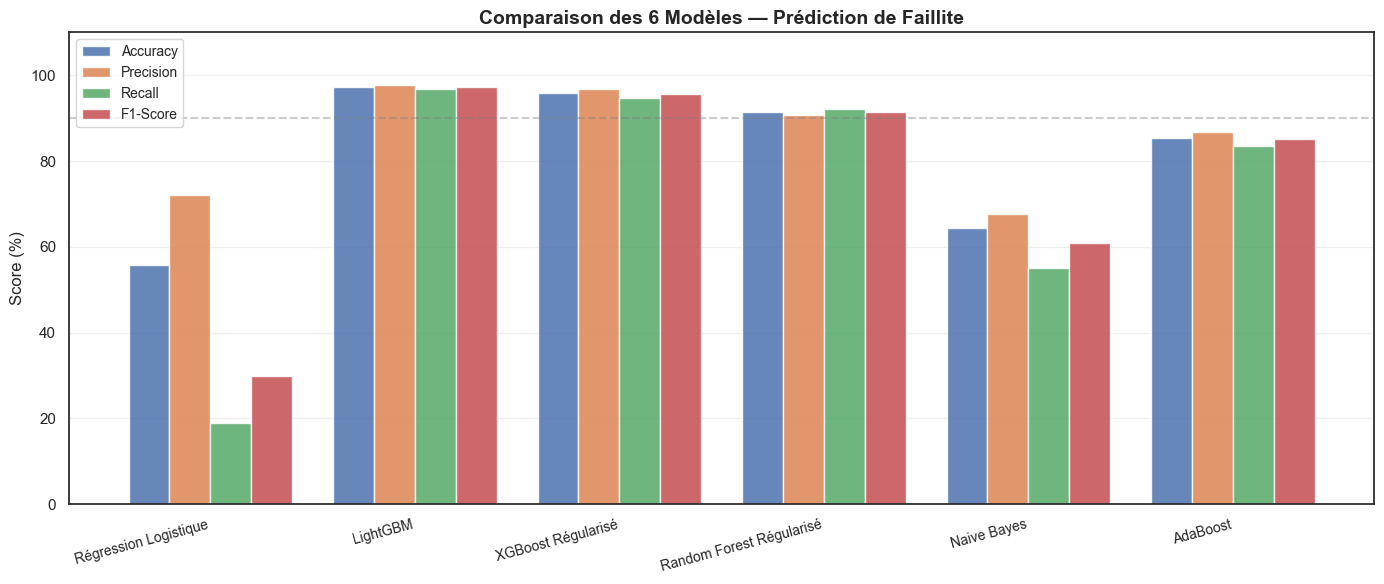

In [205]:
import matplotlib.pyplot as plt
import numpy as np

modeles   = results2['Modèle']
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
couleurs  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

x     = np.arange(len(modeles))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, couleurs)):
    ax.bar(x + i * width, results2[metric], width,
           label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(modeles, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_title('Comparaison des 6 Modèles — Prédiction de Faillite',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.4, label='Seuil 90%')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# verification des 10 variable les plus importante 

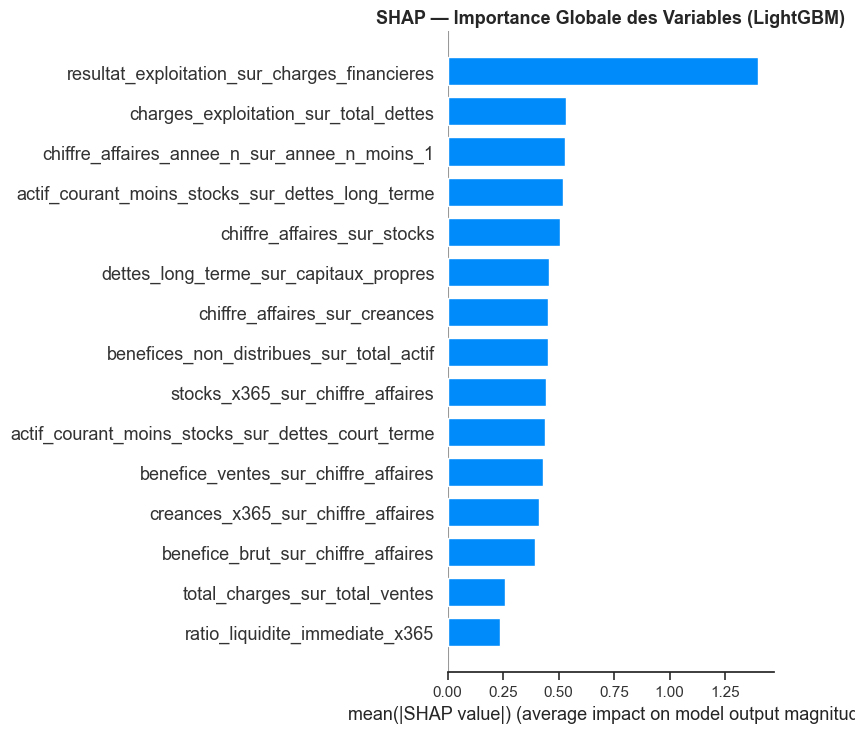

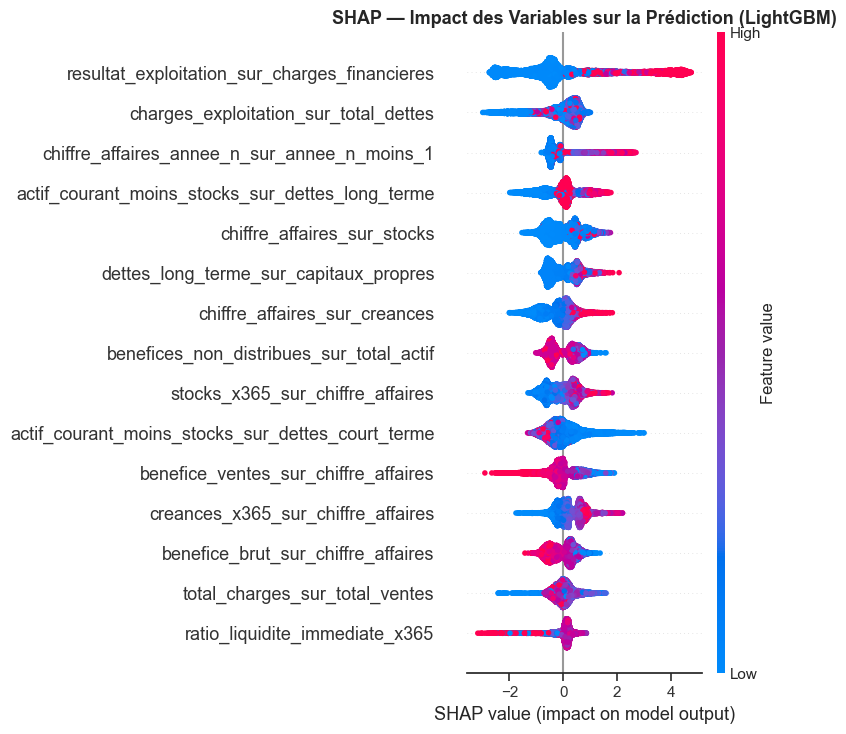


=== Explication Locale — Entreprise à risque (index 38896) ===
Prédiction réelle  : Faillite ✅
Prédiction modèle  : Faillite


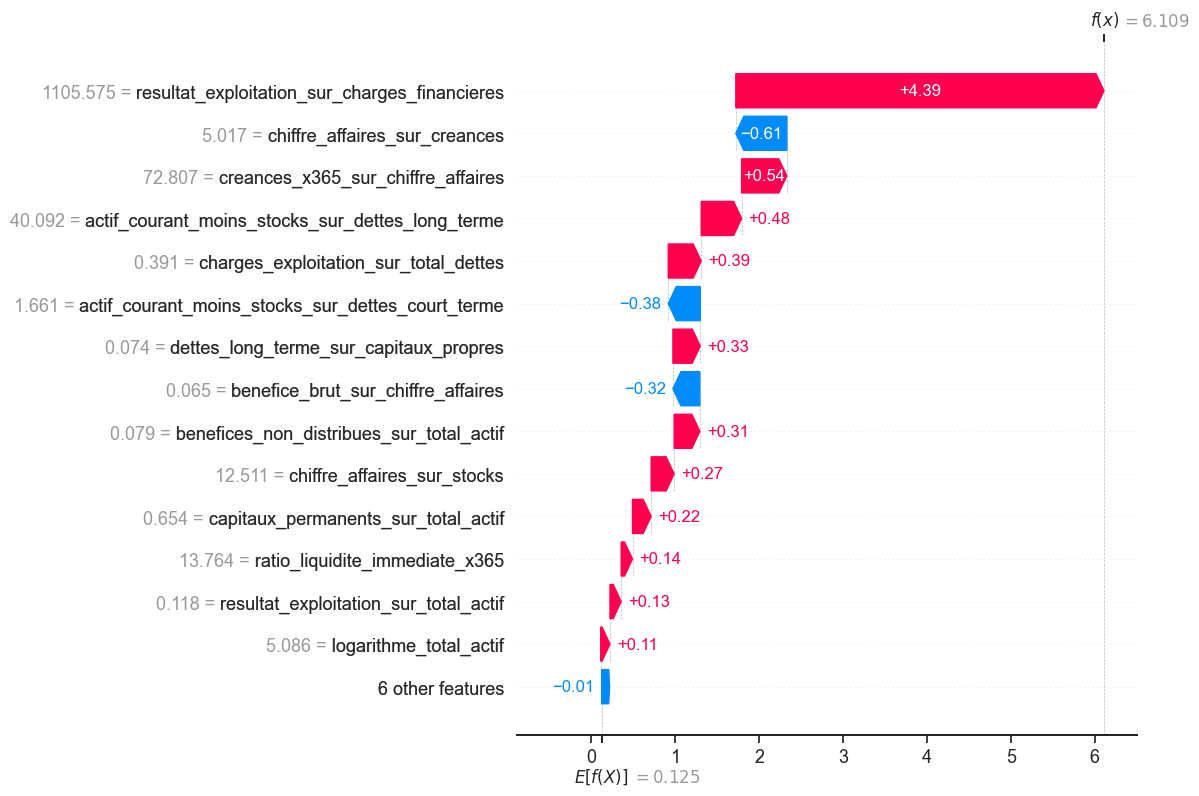


=== Top 10 Variables les plus influentes ===
                                         Variable  SHAP moyen (|v|)
    resultat_exploitation_sur_charges_financieres            1.4004
            charges_exploitation_sur_total_dettes            0.5321
     chiffre_affaires_annee_n_sur_annee_n_moins_1            0.5306
 actif_courant_moins_stocks_sur_dettes_long_terme            0.5183
                      chiffre_affaires_sur_stocks            0.5078
           dettes_long_terme_sur_capitaux_propres            0.4556
                    chiffre_affaires_sur_creances            0.4539
         benefices_non_distribues_sur_total_actif            0.4538
                 stocks_x365_sur_chiffre_affaires            0.4432
actif_courant_moins_stocks_sur_dettes_court_terme            0.4393


In [206]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# 1. Initialisation SHAP
# ================================
explainer   = shap.TreeExplainer(model4)
shap_values = explainer.shap_values(X_test)

# Pour LightGBM binaire → prendre classe 1 (Faillite)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ================================
# 2. Bar Plot — Importance Globale
# ================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importance Globale des Variables (LightGBM)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================
# 3. Beeswarm — Impact Détaillé
# ================================
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_test,
    max_display=15,
    show=False
)
plt.title('SHAP — Impact des Variables sur la Prédiction (LightGBM)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================
# 4. Waterfall — Explication Locale
#    (une entreprise en faillite)
# ================================

# Trouver un exemple de faillite réelle
idx_faillite = y_test[y_test == 1].index[0]
pos          = X_test.index.get_loc(idx_faillite)

print(f"\n=== Explication Locale — Entreprise à risque (index {idx_faillite}) ===")
print(f"Prédiction réelle  : Faillite ✅")
print(f"Prédiction modèle  : {'Faillite' if model4.predict(X_test.iloc[[pos]])[0] == 1 else 'Saine'}")

shap.waterfall_plot(
    shap.Explanation(
        values        = sv[pos],
        base_values   = explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                        else explainer.expected_value,
        data          = X_test.iloc[pos].values,
        feature_names = X_test.columns.tolist()
    ),
    max_display=15,
    show=True
)

# ================================
# 5. Tableau SHAP — Top 10 variables
# ================================
shap_importance = pd.DataFrame({
    'Variable'        : X_test.columns,
    'SHAP moyen (|v|)': abs(sv).mean(axis=0)
}).sort_values('SHAP moyen (|v|)', ascending=False).head(10)

print("\n=== Top 10 Variables les plus influentes ===")
print(shap_importance.round(4).to_string(index=False))

# validation du model retenue apres entrainement

In [207]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Sauvegarder le modèle et les noms de colonnes
joblib.dump(model4, 'models/lightgbm_best_model.pkl')
joblib.dump(list(X_test.columns), 'models/feature_names.pkl')

print("✅ Modèle sauvegardé")
print("✅ Features sauvegardées :", list(X_test.columns))

✅ Modèle sauvegardé
✅ Features sauvegardées : ['actif_courant_sur_dettes_court_terme', 'ratio_liquidite_immediate_x365', 'benefices_non_distribues_sur_total_actif', 'benefice_brut_sur_chiffre_affaires', 'stocks_x365_sur_chiffre_affaires', 'chiffre_affaires_annee_n_sur_annee_n_moins_1', 'resultat_exploitation_sur_total_actif', 'resultat_exploitation_sur_charges_financieres', 'logarithme_total_actif', 'charges_exploitation_sur_total_dettes', 'actif_courant_moins_stocks_sur_dettes_long_terme', 'capitaux_permanents_sur_total_actif', 'benefice_ventes_sur_chiffre_affaires', 'creances_x365_sur_chiffre_affaires', 'actif_courant_moins_stocks_sur_dettes_court_terme', 'fonds_de_roulement_brut', 'total_charges_sur_total_ventes', 'dettes_long_terme_sur_capitaux_propres', 'chiffre_affaires_sur_stocks', 'chiffre_affaires_sur_creances']


In [208]:
import joblib
import os

# Top 10 features SHAP
top10_features = [
    'resultat_exploitation_sur_charges_financieres',
    'charges_exploitation_sur_total_dettes',
    'chiffre_affaires_annee_n_sur_annee_n_moins_1',
    'actif_courant_moins_stocks_sur_dettes_long_terme',
    'chiffre_affaires_sur_stocks',
    'dettes_long_terme_sur_capitaux_propres',
    'chiffre_affaires_sur_creances',
    'benefices_non_distribues_sur_total_actif',
    'stocks_x365_sur_chiffre_affaires',
    'actif_courant_moins_stocks_sur_dettes_court_terme'
]

# Réentraîner LightGBM sur les 10 features uniquement
from lightgbm import LGBMClassifier

X_train_top10 = X_train[top10_features]
X_test_top10  = X_test[top10_features]

model_top10 = LGBMClassifier(class_weight='balanced', random_state=42)
model_top10.fit(X_train_top10, y_train)

# Vérification rapide
from sklearn.metrics import classification_report
y_pred_top10 = model_top10.predict(X_test_top10)
print(classification_report(y_test, y_pred_top10,
      target_names=['Saine (0)', 'Faillite (1)']))

# Sauvegarde
os.makedirs('models', exist_ok=True)
joblib.dump(model_top10, 'models/lightgbm_best_model.pkl')
joblib.dump(top10_features, 'models/feature_names.pkl')
print("✅ Modèle top10 sauvegardé !")

[LightGBM] [Info] Number of positive: 24027, number of negative: 24028
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 48055, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

   Saine (0)       0.94      0.96      0.95      8009
Faillite (1)       0.96      0.94      0.95      8010

    accuracy                           0.95     16019
   macro avg       0.95      0.95      0.95     16019
weighted avg       0.95      0.95      0.95     16019

✅ Modèle top10 sauvegardé !


# NB


Les ratios se divisent en 2 catégories opposées
Catégorie 1 — Valeur élevée = DANGER (faillite probable)
dettes_long_terme_sur_capitaux_propres     →  élevé = trop endetté
stocks_x365_sur_chiffre_affaires           →  élevé = stocks qui ne se vendent pas
creances_x365_sur_chiffre_affaires         →  élevé = clients qui ne paient pas
ratio_liquidite_immediate_x365             →  très élevé = anomalie comptable

Catégorie 2 — Valeur élevée = BONNE SANTÉ (entreprise saine)
resultat_exploitation_sur_charges_fin      →  élevé = très rentable
benefices_non_distribues_sur_total_actif   →  élevé = bénéfices accumulés
chiffre_affaires_sur_creances              →  élevé = clients paient vite
chiffre_affaires_sur_stocks                →  élevé = stocks qui tournent bien
capitaux_permanents_sur_total_actif        →  élevé = bonne structure financière